In [7]:
# Environment/config setup for only_mouse7 analysis
import os, sys, importlib

# Ensure we import suns from this repo
sys.path.insert(0, "/gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS")
for m in [k for k in list(sys.modules) if k == 'suns' or k.startswith('suns.')]:
    del sys.modules[m]

from suns import config as suns_config
suns_config = importlib.reload(suns_config)
print("Using config:", getattr(suns_config, "__file__", "<unknown>"))
print("'4videos_mouse7' in EXP_ID_SETS?", '4videos_mouse7' in suns_config.EXP_ID_SETS)


importing config
importing config
Using config: /gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/suns/config.py
'4videos_mouse7' in EXP_ID_SETS? True


In [15]:
# Build mouse7 datasets without any overrides
import os, importlib

# Ensure ACTIVE_SETS only includes mouse7 subsets
ACTIVE_SETS = [
    ('mouse7 4 videos', '4videos_mouse7'),
    ('mouse7 8 videos', '8videos_mouse7'),
]

# No overrides: use default folders from suns.config
PARENT_OVERRIDES = {}

# Build per-setup paths for downstream analysis
DATASETS = []  # [{label,set_key,list_Exp_ID,dir_video,dir_parent,dir_net_in,weights_path,dir_output}]
for label, set_key in ACTIVE_SETS:
    list_Exp_ID = suns_config.EXP_ID_SETS[set_key]
    dir_video = suns_config.DATAFOLDER_SETS[set_key]
    parent = os.path.join(dir_video, suns_config.OUTPUT_FOLDER[set_key])
    ds = {
        'label': label,
        'set_key': set_key,
        'list_Exp_ID': list_Exp_ID,
        'dir_video': dir_video,
        'dir_parent': parent,
        'dir_net_in': os.path.join(parent, 'network_input'),
        'weights_path': os.path.join(parent, 'Weights'),
        'dir_output': os.path.join(parent, 'output_masks'),
    }
    DATASETS.append(ds)
    print(f"[cfg] {label}: parent={parent}")

# Convenience: a default exp id (first of the first dataset)
DEFAULT_EXP_ID = DATASETS[0]['list_Exp_ID'][0]
print('Default exp id:', DEFAULT_EXP_ID)


[cfg] mouse7 4 videos: parent=/gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/only_mouse7/output_4videos_mouse7
[cfg] mouse7 8 videos: parent=/gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/only_mouse7/output_8videos_mouse7
Default exp id: mouse7_773


# Mouse 7 - Analysis

This notebook loads mouse7 data, 
- plots max projection with GT and predicted masks, 
- visualizes ROI area distributions,
- compute and visualize ROIs shape 



In [16]:
# Helpers needed by the analysis function (Py 3.8+ compatible typing)

import numpy as np, h5py

# Pick which dataset and experiment to run
ds = DATASETS[0]  # 0 = 'mouse7 4 videos', 1 = 'mouse7 8 videos'
exp_id = ds['list_Exp_ID'][0]  # or choose another from ds['list_Exp_ID']

# Bind paths for this run
dir_video = ds['dir_video']
dir_parent = ds['dir_parent']
dir_net_in = ds['dir_net_in']
dir_output = ds['dir_output']

print(f"Running {ds['set_key']} / {exp_id}")

from typing import Tuple
import numpy as np, h5py
from scipy.io import loadmat
from scipy.sparse import csc_matrix

def compute_max_projection_from_h5(h5_path: str) -> np.ndarray:
    with h5py.File(h5_path, 'r') as f:
        from suns.PreProcessing.preprocessing_functions import find_dataset
        dset_name = find_dataset(f)
        dset = f[dset_name]
        nframes = dset.shape[0]
        max_img = np.array(dset[0], dtype=np.float32)
        for i in range(1, nframes):
            np.maximum(max_img, dset[i], out=max_img)
    vmin, vmax = float(max_img.min()), float(max_img.max())
    return (max_img - vmin) / (vmax - vmin) if vmax > vmin else np.zeros_like(max_img, dtype=np.float32)

def load_gt_sparse_masks(gt_sparse_path: str, dims: Tuple[int, int]) -> np.ndarray:
    Lx, Ly = dims
    md = loadmat(gt_sparse_path)
    GT = csc_matrix(md['GTMasks_2'])
    pixels = Lx * Ly
    if GT.shape[0] == pixels and GT.shape[1] != pixels:
        GTp = GT
    elif GT.shape[1] == pixels and GT.shape[0] != pixels:
        GTp = GT.transpose()
    else:
        GTp = GT
    n_gt = GTp.shape[1]
    masks = np.zeros((n_gt, Lx, Ly), dtype=bool)
    for j in range(n_gt):
        idx = GTp.getcol(j).indices
        masks[j].ravel()[idx] = True
    return masks

def load_pred_masks_from_mat(out_mat_path: str, dims: Tuple[int, int]) -> np.ndarray:
    Lx, Ly = dims
    md = loadmat(out_mat_path)
    m = md.get('Masks')
    if m is None:
        raise RuntimeError("'Masks' not found in output mat")
    m = np.asarray(m)
    if m.ndim != 3:
        raise ValueError(f"Masks must be 3D, got shape {m.shape}")

    dims_set = {int(Lx), int(Ly)}
    shape = tuple(int(x) for x in m.shape)
    non_spatial_axes = [ax for ax, sz in enumerate(shape) if sz not in dims_set]

    if len(non_spatial_axes) == 1:
        aN = non_spatial_axes[0]
        other = [ax for ax in range(3) if ax != aN]
        ax_lx = next(ax for ax in other if shape[ax] == Lx)
        ax_ly = next(ax for ax in other if ax != ax_lx)
        masks = np.transpose(m.astype(bool), (aN, ax_lx, ax_ly))
        if masks.shape[1:] == (Ly, Lx):
            masks = np.transpose(masks, (0, 2, 1))
    else:
        masks = np.transpose(m.astype(bool), (2, 0, 1))
        if masks.shape[1:] == (Ly, Lx):
            masks = np.transpose(masks, (0, 2, 1))

    if masks.shape[1:] != (Lx, Ly):
        if masks.shape[1:] == (Ly, Lx):
            masks = np.transpose(masks, (0, 2, 1))
        else:
            raise ValueError(f"Masks spatial dims {masks.shape[1:]} do not match expected {(Lx, Ly)}")
    return masks

def pad_masks_top_left(masks: np.ndarray, target_dims: Tuple[int, int]) -> np.ndarray:
    if masks.ndim != 3:
        raise ValueError('masks must be (N, Lx, Ly)')
    n, Lx_src, Ly_src = masks.shape
    Lx_tgt, Ly_tgt = target_dims
    if (Lx_src, Ly_src) == (Lx_tgt, Ly_tgt):
        return masks
    out = np.zeros((n, Lx_tgt, Ly_tgt), dtype=masks.dtype)
    out[:, :Lx_src, :Ly_src] = masks
    return out

def transform_masks(masks: np.ndarray, rot_k: int = 0, flip_ud: bool = False, flip_lr: bool = False) -> np.ndarray:
    if masks.ndim != 3:
        return masks
    out = masks
    rk = rot_k % 4
    if rk:
        out = np.rot90(out, k=rk, axes=(1, 2))
    if flip_ud:
        out = np.flip(out, axis=1)
    if flip_lr:
        out = np.flip(out, axis=2)
    return out

Running 4videos_mouse7 / mouse7_773


In [19]:
import os, importlib, h5py, numpy as np

# Pick dataset/experiment and bind paths
ds = DATASETS[0]  # 0: 4videos_mouse7, 1: 8videos_mouse7
exp_id = ds['list_Exp_ID'][0]  # or choose any in ds['list_Exp_ID']
dir_video = ds['dir_video']
dir_parent = ds['dir_parent']
dir_net_in = ds['dir_net_in']
dir_output = ds['dir_output']

# Diagnostics
print("set_key:", ds['set_key'])
print("dir_net_in:", dir_net_in)
print("exp_id:", exp_id)

h5_net_in = os.path.join(dir_net_in, f"{exp_id}.h5")
print("h5_net_in:", h5_net_in)
print("dir exists?", os.path.isdir(dir_net_in))
print("file exists?", os.path.exists(h5_net_in))

# If anything looks off, rebuild dir_net_in from config to be safe
if not os.path.isdir(dir_net_in):
    from suns import config as suns_config
    dir_net_in = os.path.join(
        suns_config.DATAFOLDER_SETS[ds['set_key']],
        suns_config.OUTPUT_FOLDER[ds['set_key']],
        "network_input"
    )
    print("rebuilt dir_net_in:", dir_net_in)
    h5_net_in = os.path.join(dir_net_in, f"{exp_id}.h5")
    print("rebuilt h5_net_in:", h5_net_in)

set_key: 4videos_mouse7
dir_net_in: /gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/only_mouse7/output_4videos_mouse7/network_input
exp_id: mouse7_773
h5_net_in: /gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/only_mouse7/output_4videos_mouse7/network_input/mouse7_773.h5
dir exists? False
file exists? False
rebuilt dir_net_in: /gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/only_mouse7/output_4videos_mouse7/network_input
rebuilt h5_net_in: /gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/only_mouse7/output_4videos_mouse7/network_input/mouse7_773.h5


In [20]:
# --- Load data and compute max projection ---
# Prefer the preprocessed network_input for consistency with pipeline
h5_net_in = os.path.join(dir_net_in, f'{exp_id}.h5')
if os.path.exists(h5_net_in):
    with h5py.File(h5_net_in, 'r') as f:
        network_input = np.array(f['network_input'])  # (T, Lx, Ly)
    T, Lx, Ly = network_input.shape
    max_img = network_input.max(axis=0).astype(np.float32)
    vmin, vmax = float(max_img.min()), float(max_img.max())
    if vmax > vmin:
        max_img = (max_img - vmin) / (vmax - vmin)
else:
    # Fallback to raw video
    raw_h5 = os.path.join(dir_video, f'{exp_id}.h5')
    assert os.path.exists(raw_h5), f'Missing video: {raw_h5}'
    max_img = compute_max_projection_from_h5(raw_h5)
    Lx, Ly = max_img.shape

# Load masks
gt_sparse = os.path.join(dir_video, 'GT Masks', f'FinalMasks_{exp_id}_sparse.mat')
if os.path.exists(gt_sparse):
    gt_masks = load_gt_sparse_masks(gt_sparse, (Lx, Ly))
else:
    gt_masks = np.zeros((0, Lx, Ly), dtype=bool)

pred_mat = os.path.join(dir_output, f'Output_Masks_{exp_id}.mat')
if os.path.exists(pred_mat):
    pred_masks = load_pred_masks_from_mat(pred_mat, (Lx, Ly))
else:
    pred_masks = np.zeros((0, Lx, Ly), dtype=bool)

n_gt = gt_masks.shape[0]
n_pred = pred_masks.shape[0]
print(f'N_GT={n_gt}, N_pred={n_pred}, shape={Lx}x{Ly}')


KeyboardInterrupt: 

In [18]:
# --- Preview raw video and SNR-normalized video (end of preprocessing) ---
import os, h5py
import numpy as np
import matplotlib.pyplot as plt

# Paths
raw_h5 = os.path.join(dir_video, f'{exp_id}.h5')
h5_net_in = os.path.join(dir_net_in, f'{exp_id}.h5')

# Load SNR (network_input) stack if not in memory
if 'network_input' not in globals():
    assert os.path.exists(h5_net_in), f'Missing network_input: {h5_net_in}'
    with h5py.File(h5_net_in, 'r') as f:
        network_input = np.array(f['network_input'])  # (T, Y, X)

# Load raw stack shape and a representative frame without reading entire movie
assert os.path.exists(raw_h5), f'Missing raw video: {raw_h5}'
with h5py.File(raw_h5, 'r') as f:
    dset_name = find_dataset(f)  # helper defined earlier
    dset = f[dset_name]
    T_raw = dset.shape[0]
    # pick a middle frame for preview
    t0 = int(T_raw // 2)
    raw_frame = dset[t0].astype(np.float32)

# SNR frame at same index (clamp if lengths differ)
T_snr = network_input.shape[0]
t1 = min(t0, T_snr - 1)
snr_frame = network_input[t1].astype(np.float32)

# Normalize frames for display using robust percentiles
def normalize_img(img):
    p1, p99 = np.percentile(img, (1, 99))
    if p99 > p1:
        img = (img - p1) / (p99 - p1)
    return np.clip(img, 0, 1)

raw_frame_n = normalize_img(raw_frame)
snr_frame_n = normalize_img(snr_frame)

# Max projections (robust-normalized)
raw_max = normalize_img(compute_max_projection_from_h5(raw_h5))
snr_max = normalize_img(network_input.max(axis=0).astype(np.float32))

# Plot 2x2: raw frame, snr frame, raw max, snr max
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
axes = axes.ravel()

axes[0].imshow(raw_frame_n, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Raw frame (middle)')
axes[0].axis('off')

axes[1].imshow(snr_frame_n, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('SNR-normalized frame (middle)')
axes[1].axis('off')

axes[2].imshow(raw_max, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Raw max projection')
axes[2].axis('off')

axes[3].imshow(snr_max, cmap='gray', vmin=0, vmax=1)
axes[3].set_title('SNR max projection')
axes[3].axis('off')

plt.suptitle(f'{exp_id}: Raw vs SNR preview', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.965])

out_png_preview = os.path.join(dir_parent, f'raw_snr_preview_{exp_id}.png')
plt.savefig(out_png_preview, dpi=200)
print('Saved preview to:', out_png_preview)
plt.show()


AssertionError: Missing network_input: /gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/only_mouse7/output_4videos_mouse7/network_input/mouse7_773.h5

In [17]:
# --- Align GT/Pred to network_input grid while keeping network_input max projection ---
# Read raw dims (fast) and rebuild GT accordingly, then pad to (Lx, Ly)
GT_ROT_K = 1 # default; may be overridden by auto-align
GT_FLIPUD = False
GT_FLIPLR = False

PRED_ROT_K = 0 # default; may be overridden by auto-align
PRED_FLIPUD = False
PRED_FLIPLR = False

raw_h5 = os.path.join(dir_video, f'{exp_id}.h5')
assert os.path.exists(raw_h5), f'Missing video: {raw_h5}'
with h5py.File(raw_h5, 'r') as f:
    dset_name = find_dataset(f)
    Lx_raw, Ly_raw = f[dset_name].shape[1:3]  # no full read, just shape

# Rebuild GT from raw dims
if os.path.exists(gt_sparse):
    gt_masks_raw = load_gt_sparse_masks(gt_sparse, (Lx_raw, Ly_raw))
else:
    gt_masks_raw = np.zeros((0, Lx_raw, Ly_raw), dtype=bool)

# Target dims = network_input dims if available
if 'network_input' in globals():
    Lx_net, Ly_net = network_input.shape[1:]
    max_img_net = network_input.max(axis=0).astype(np.float32)
    vmin_, vmax_ = float(max_img_net.min()), float(max_img_net.max())
    if vmax_ > vmin_:
        max_img_net = (max_img_net - vmin_) / (vmax_ - vmin_)
else:
    Lx_net, Ly_net = Lx, Ly
    # reuse max_img computed earlier
    max_img_net = max_img.astype(np.float32)

# --- Auto-align by maximizing mean max-projection intensity under masks ---
from itertools import product

def _score_alignment(masks_bool, img_f32):
    if masks_bool.size == 0:
        return -np.inf
    # Reduce 3D stacks (N, Lx, Ly) to a 2D union mask for scoring against 2D max projection
    if masks_bool.ndim == 3:
        union = np.any(masks_bool, axis=0)
    elif masks_bool.ndim == 2:
        union = masks_bool
    else:
        return -np.inf
    area = int(union.sum())
    if area == 0:
        return -np.inf
    return float(img_f32[union].mean())

combos = [(k, u, l) for k in range(4) for u in (False, True) for l in (False, True)]

def _best_transform_for_masks(masks_src, src_dims, tgt_dims, img_tgt):
    best = (-np.inf, 0, False, False, None)
    for rk, fud, flr in combos:
        m_tf = transform_masks(masks_src, rot_k=rk, flip_ud=fud, flip_lr=flr)
        # pad/crop to target dims (top-left pad)
        if m_tf.shape[1:] != tgt_dims:
            m_tf = pad_masks_top_left(m_tf, tgt_dims)
        score = _score_alignment(m_tf, img_tgt)
        if score > best[0]:
            best = (score, rk, fud, flr, m_tf)
    return best  # (score, rk, fud, flr, masks_aligned)

# Choose best transform for GT (from raw -> net)
_, GT_ROT_K, GT_FLIPUD, GT_FLIPLR, gt_masks = _best_transform_for_masks(
    gt_masks_raw, (Lx_raw, Ly_raw), (Lx_net, Ly_net), max_img_net
)

# Choose best transform for Pred (handle either raw-sized or net-sized inputs)
if pred_masks.shape[1:] == (Lx_raw, Ly_raw):
    _, PRED_ROT_K, PRED_FLIPUD, PRED_FLIPLR, pred_masks = _best_transform_for_masks(
        pred_masks, (Lx_raw, Ly_raw), (Lx_net, Ly_net), max_img_net
    )
else:
    _, PRED_ROT_K, PRED_FLIPUD, PRED_FLIPLR, pred_masks = _best_transform_for_masks(
        pred_masks, pred_masks.shape[1:], (Lx_net, Ly_net), max_img_net
    )

# Update counters and dimensions for plotting
Lx, Ly = Lx_net, Ly_net
n_gt = gt_masks.shape[0]
n_pred = pred_masks.shape[0]
print(
    f'Aligned: raw={Lx_raw}x{Ly_raw} -> net_in={Lx}x{Ly}; '
    f'N_GT={n_gt}, N_pred={n_pred}; '
    f'GT(rot={GT_ROT_K},ud={GT_FLIPUD},lr={GT_FLIPLR}), '
    f'PRED(rot={PRED_ROT_K},ud={PRED_FLIPUD},lr={PRED_FLIPLR})'
)


NameError: name 'find_dataset' is not defined

Saved overlay to: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3/overlay_mouse7.png


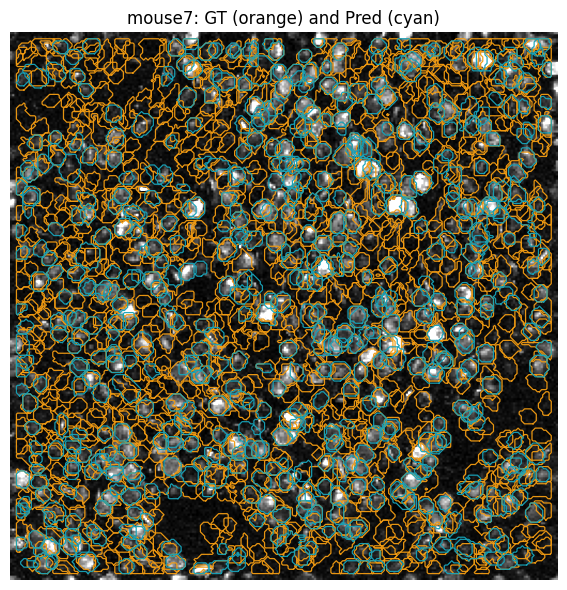

Saved triptych to: /gpfs/data/shohamlab/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3/overlay_triptych_mouse7.png


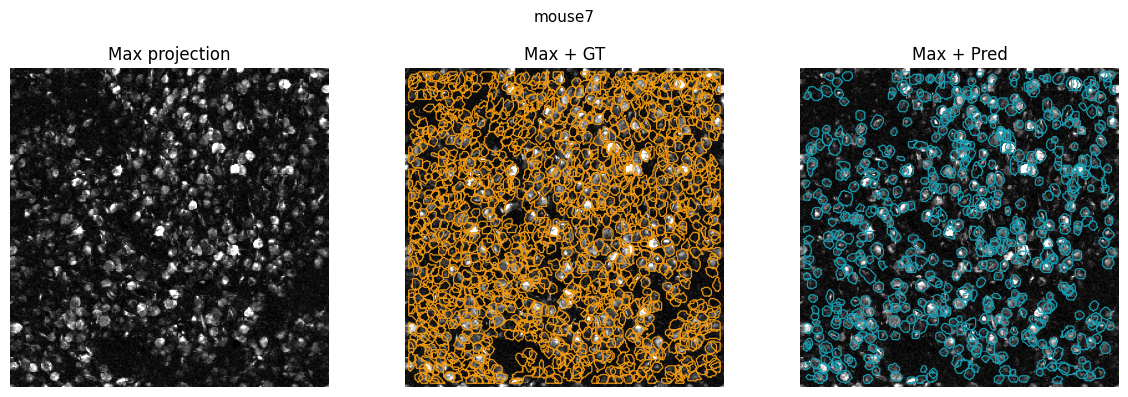

In [6]:
# --- Static overlay (no GUI) of GT & Pred on max projection ---
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure


def plot_overlay_maxproj(max_img, gt_masks, pred_masks, out_path=None):
    fig, ax = plt.subplots(figsize=(6, 6))
    vmin, vmax = np.percentile(max_img, (1, 99))
    ax.imshow(max_img, cmap='gray', vmin=vmin, vmax=vmax)

    # GT in orange
    for i in range(gt_masks.shape[0]):
        m = gt_masks[i]
        if m.any():
            for c in measure.find_contours(m.astype(float), 0.5):
                ax.plot(c[:, 1], c[:, 0], color='#F39C12', lw=0.9, alpha=0.95)

    # Pred in cyan
    for i in range(pred_masks.shape[0]):
        m = pred_masks[i]
        if m.any():
            for c in measure.find_contours(m.astype(float), 0.5):
                ax.plot(c[:, 1], c[:, 0], color='#17A2B8', lw=0.9, alpha=0.95)

    ax.set_title(f"{exp_id}: GT (orange) and Pred (cyan)")
    ax.axis('off')
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=200)
        print('Saved overlay to:', out_path)
    plt.show()


def _draw_contours(ax, masks, color, lw=0.9, alpha=0.95):
    for i in range(masks.shape[0]):
        m = masks[i]
        if m.any():
            for c in measure.find_contours(m.astype(float), 0.5):
                ax.plot(c[:, 1], c[:, 0], color=color, lw=lw, alpha=alpha)


def plot_overlay_triptych(max_img, gt_masks, pred_masks, out_path=None):
    vmin, vmax = np.percentile(max_img, (1, 99))
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # 1) Max projection only
    axes[0].imshow(max_img, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0].set_title('Max projection')
    axes[0].axis('off')

    # 2) Max + GT
    axes[1].imshow(max_img, cmap='gray', vmin=vmin, vmax=vmax)
    _draw_contours(axes[1], gt_masks, color='#F39C12')
    axes[1].set_title('Max + GT')
    axes[1].axis('off')

    # 3) Max + Pred
    axes[2].imshow(max_img, cmap='gray', vmin=vmin, vmax=vmax)
    _draw_contours(axes[2], pred_masks, color='#17A2B8')
    axes[2].set_title('Max + Pred')
    axes[2].axis('off')

    fig.suptitle(exp_id, y=0.98, fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if out_path:
        plt.savefig(out_path, dpi=200)
        print('Saved triptych to:', out_path)
    plt.show()

# Ensure we have a max image
if 'max_img' not in globals():
    if 'network_input' in globals():
        max_img = network_input.max(axis=0).astype(np.float32)
        vmin, vmax = float(max_img.min()), float(max_img.max())
        if vmax > vmin:
            max_img = (max_img - vmin) / (vmax - vmin)
    else:
        raw_h5 = os.path.join(dir_video, f'{exp_id}.h5')
        assert os.path.exists(raw_h5), f'Missing video: {raw_h5}'
        max_img = compute_max_projection_from_h5(raw_h5)

# Save next to outputs
out_png = os.path.join(dir_parent, f'overlay_{exp_id}.png')
plot_overlay_maxproj(max_img, gt_masks, pred_masks, out_path=out_png)

# Triptych (1x3) figure
out_png3 = os.path.join(dir_parent, f'overlay_triptych_{exp_id}.png')
plot_overlay_triptych(max_img, gt_masks, pred_masks, out_path=out_png3)



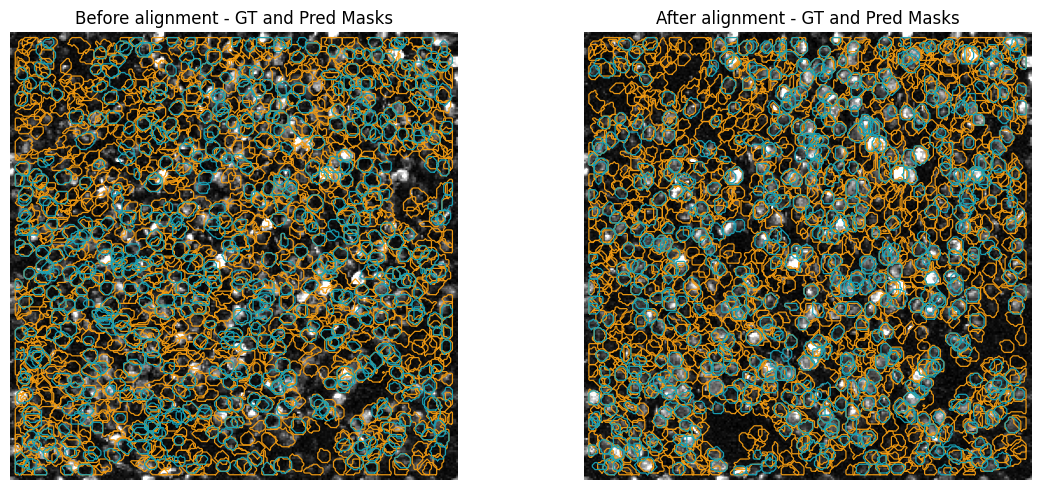

In [7]:
# --- Visual check: before vs after alignment overlays ---
# Use raw GT and re-loaded raw Pred to show why alignment is needed.

# Re-load original predicted masks in raw orientation (unaligned)
pred_masks_unaligned = load_pred_masks_from_mat(pred_mat, (Lx_raw, Ly_raw))
# Raw GT was already built as gt_masks_raw
gt_masks_unaligned = gt_masks_raw

# Ensure unaligned masks are on the network_input grid (no rotations/flips)
Lx_net, Ly_net = int(Lx_net), int(Ly_net)
gt_bef = gt_masks_unaligned if gt_masks_unaligned.shape[1:] == (Lx_net, Ly_net) else pad_masks_top_left(gt_masks_unaligned, (Lx_net, Ly_net))
pr_bef = pred_masks_unaligned if pred_masks_unaligned.shape[1:] == (Lx_net, Ly_net) else pad_masks_top_left(pred_masks_unaligned, (Lx_net, Ly_net))

# Side-by-side figure: before vs after, both drawn on the max projection
vmin_net, vmax_net = np.percentile(max_img_net, (1, 99))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before alignment (unaligned masks on max projection)
axes[0].imshow(max_img_net, cmap='gray', vmin=vmin_net, vmax=vmax_net)
_draw_contours(axes[0], gt_bef, color='#F39C12')   # GT: orange
_draw_contours(axes[0], pr_bef, color='#17A2B8')   # Pred: cyan
axes[0].set_title('Before alignment - GT and Pred Masks')
axes[0].axis('off')

# After alignment (current gt_masks, pred_masks on net grid)
axes[1].imshow(max_img_net, cmap='gray', vmin=vmin_net, vmax=vmax_net)
_draw_contours(axes[1], gt_masks, color='#F39C12')
_draw_contours(axes[1], pred_masks, color='#17A2B8')
axes[1].set_title('After alignment - GT and Pred Masks')
axes[1].axis('off')

plt.tight_layout()
plt.show()



In [ ]:
# Windowed view: plot metrics between start_epoch and end_epoch (inclusive)
import numpy as np
import matplotlib.pyplot as plt

start_epoch = 1
end_epoch = 25

if 'curves' not in globals() or not curves:
    print('No curves dict found. Run an overlay cell first, then re-run this cell.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Dice window
    for name, dat in curves.items():
        y = dat['dice']
        e = np.arange(1, len(y) + 1)
        m = (e >= start_epoch) & (e <= end_epoch)
        if m.any():
            axes[0].plot(e[m], y[m], label=dat['label'])
    axes[0].set_title(f'Dice (epochs {start_epoch}–{end_epoch})')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Dice (higher is better)')
    axes[0].set_ylim(0.0, 1.0)
    axes[0].set_xlim(start_epoch, end_epoch)
    axes[0].grid(True, alpha=0.2)
    axes[0].legend()

    # Loss window
    any_loss = False
    for name, dat in curves.items():
        if dat.get('loss') is not None and len(dat['loss']):
            y = dat['loss']
            e = np.arange(1, len(y) + 1)
            m = (e >= start_epoch) & (e <= end_epoch)
            if m.any():
                axes[1].plot(e[m], y[m], label=dat['label'].replace('Dice', 'Loss'))
                any_loss = True
    axes[1].set_title(f'Loss (epochs {start_epoch}–{end_epoch})')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss (lower is better)')
    axes[1].set_xlim(start_epoch, end_epoch)
    axes[1].grid(True, alpha=0.2)
    if any_loss:
        axes[1].legend()

    fig.tight_layout()
    plt.show()


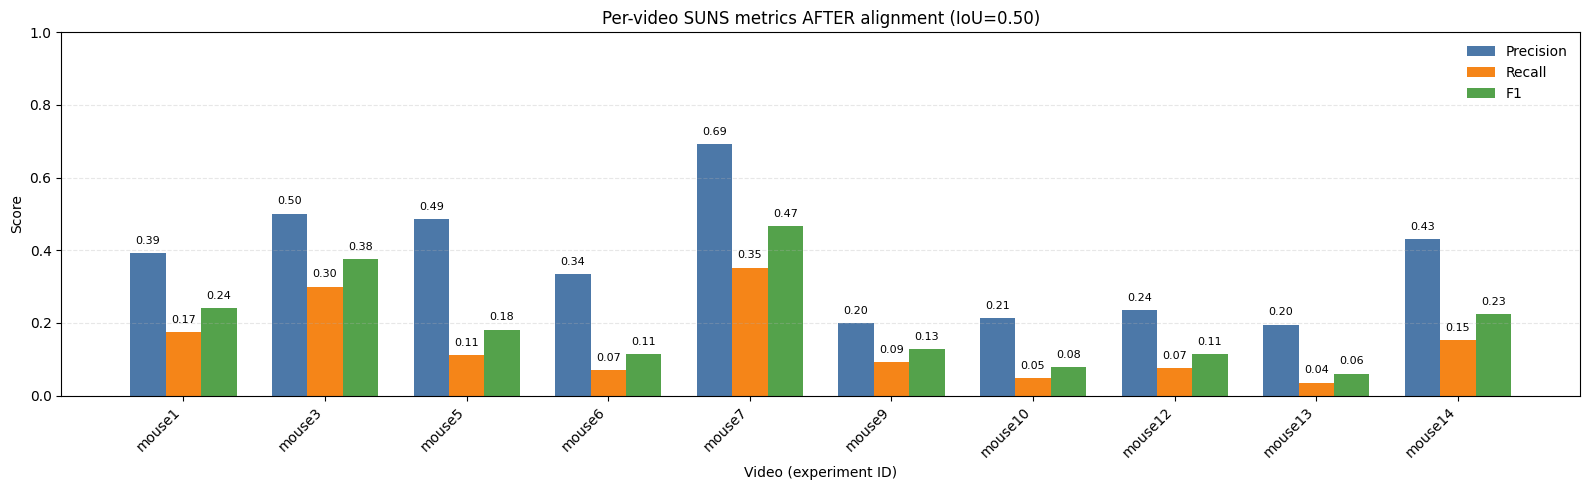

In [9]:
# --- Per-video SUNS metrics AFTER alignment (same style, names on x-axis) ---
from suns.PostProcessing.evaluate import GetPerformance_Jaccard_2
from scipy import sparse
import numpy as np
import matplotlib.pyplot as plt
import os, h5py

# IoU evaluation threshold (match the standard unless you change it)
iou_eval_after = 0.50

exp_ids = list(list_Exp_ID)
P_after, R_after, F_after = [], [], []

for eid in exp_ids:
    # Paths
    raw_h5_e   = os.path.join(dir_video, f'{eid}.h5')
    gt_sparse_e = os.path.join(dir_video, 'GT Masks', f'FinalMasks_{eid}_sparse.mat')
    pred_mat_e  = os.path.join(dir_output, f'Output_Masks_{eid}.mat')

    # Target grid = network_input when available
    h5_net_in_e = os.path.join(dir_net_in, f'{eid}.h5')
    if os.path.exists(h5_net_in_e):
        with h5py.File(h5_net_in_e, 'r') as f:
            net_in_e = np.array(f['network_input'])
        Lx_net_e, Ly_net_e = net_in_e.shape[1:]
        max_img_net_e = net_in_e.max(axis=0).astype(np.float32)
        vmin_, vmax_ = float(max_img_net_e.min()), float(max_img_net_e.max())
        if vmax_ > vmin_:
            max_img_net_e = (max_img_net_e - vmin_) / (vmax_ - vmin_)
    else:
        with h5py.File(raw_h5_e, 'r') as f:
            dset_name_e = find_dataset(f)
            Lx_net_e, Ly_net_e = f[dset_name_e].shape[1:3]
            max_img_net_e = compute_max_projection_from_h5(raw_h5_e)

    # Raw dims
    with h5py.File(raw_h5_e, 'r') as f:
        dset_name_e = find_dataset(f)
        Lx_raw_e, Ly_raw_e = f[dset_name_e].shape[1:3]

    # Load raw GT / Pred
    gt_raw_e = load_gt_sparse_masks(gt_sparse_e, (Lx_raw_e, Ly_raw_e)) if os.path.exists(gt_sparse_e) else np.zeros((0, Lx_raw_e, Ly_raw_e), dtype=bool)
    pred_e   = load_pred_masks_from_mat(pred_mat_e, (Lx_raw_e, Ly_raw_e)) if os.path.exists(pred_mat_e) else np.zeros((0, Lx_raw_e, Ly_raw_e), dtype=bool)

    # Align to target grid using the same helper as earlier in the notebook
    _, _, _, _, gt_aligned_e = _best_transform_for_masks(gt_raw_e, (Lx_raw_e, Ly_raw_e), (Lx_net_e, Ly_net_e), max_img_net_e)
    if pred_e.shape[1:] == (Lx_raw_e, Ly_raw_e):
        _, _, _, _, pred_aligned_e = _best_transform_for_masks(pred_e, (Lx_raw_e, Ly_raw_e), (Lx_net_e, Ly_net_e), max_img_net_e)
    else:
        _, _, _, _, pred_aligned_e = _best_transform_for_masks(pred_e, pred_e.shape[1:], (Lx_net_e, Ly_net_e), max_img_net_e)

    # SUNS evaluation at IoU threshold
    GT_csr  = sparse.csr_matrix(gt_aligned_e.reshape(gt_aligned_e.shape[0], -1).astype(np.uint32))
    PR_csr  = sparse.csr_matrix(pred_aligned_e.reshape(pred_aligned_e.shape[0], -1).astype(np.uint32))
    ThreshJ = 1.0 - float(iou_eval_after)
    R, P, F1 = GetPerformance_Jaccard_2(GT_csr, PR_csr, ThreshJ=ThreshJ)
    P_after.append(float(P)); R_after.append(float(R)); F_after.append(float(F1))

# Plot in same grouped style
N = len(exp_ids)
x = np.arange(N); w = 0.25
plt.figure(figsize=(max(10, 1.6*N), 5))
plt.bar(x - w, P_after, width=w, label='Precision', color='#4C78A8')
plt.bar(x,      R_after, width=w, label='Recall',    color='#F58518')
plt.bar(x + w,  F_after, width=w, label='F1',        color='#54A24B')
plt.xticks(x, exp_ids, rotation=45, ha='right')
plt.ylim(0, 1.0)
plt.xlabel('Video (experiment ID)')
plt.ylabel('Score')
plt.title(f'Per-video SUNS metrics AFTER alignment (IoU={iou_eval_after:.2f})')
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.legend(frameon=False)

# annotate values
for i in range(N):
    for j, v in enumerate([P_after[i], R_after[i], F_after[i]]):
        xpos = x[i] + (j-1)*w
        plt.text(xpos, min(0.98, v + 0.02), f'{v:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout(); plt.show()



mouse1: IoU=0.20  P=0.816  R=0.363  F1=0.502
mouse3: IoU=0.20  P=0.803  R=0.481  F1=0.602
mouse5: IoU=0.20  P=0.876  R=0.200  F1=0.326
mouse6: IoU=0.20  P=0.860  R=0.178  F1=0.295
mouse7: IoU=0.20  P=0.867  R=0.441  F1=0.585
mouse9: IoU=0.20  P=0.546  R=0.254  F1=0.346
mouse10: IoU=0.20  P=0.662  R=0.147  F1=0.241
mouse12: IoU=0.20  P=0.590  R=0.187  F1=0.284
mouse13: IoU=0.20  P=0.630  R=0.115  F1=0.194
mouse14: IoU=0.20  P=0.646  R=0.228  F1=0.337


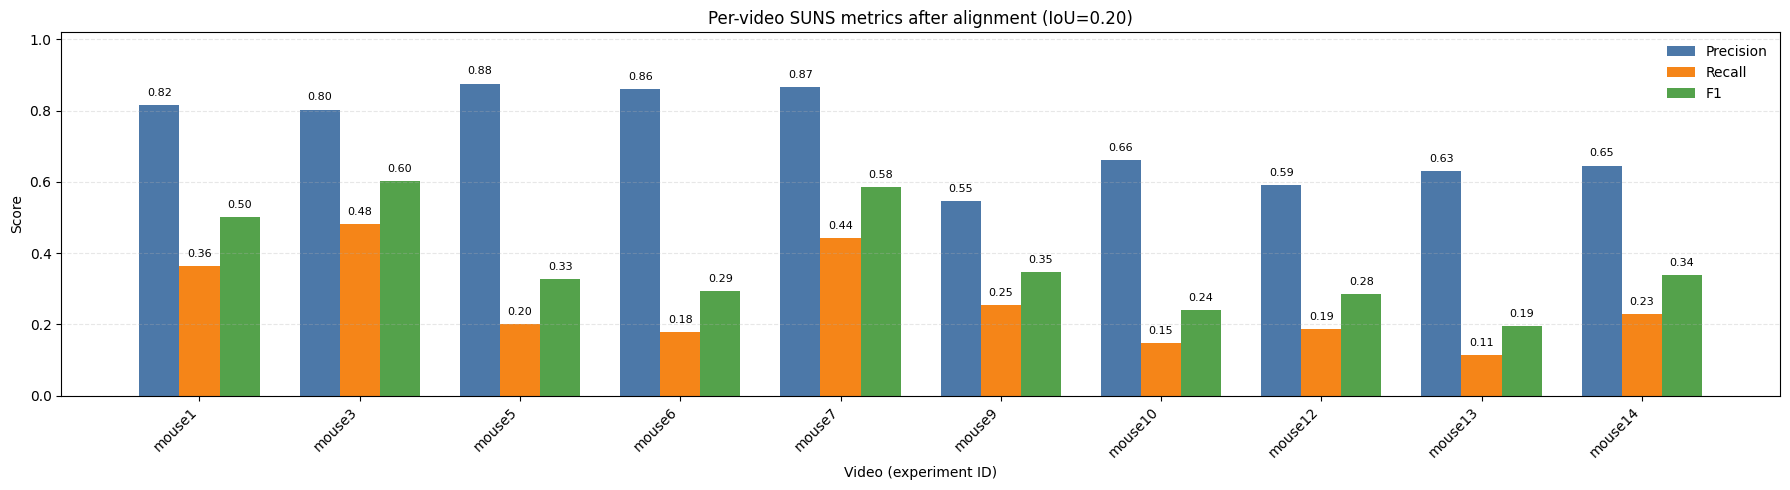

In [ ]:
# --- Per-video SUNS metrics after alignment (mouse names on x-axis) ---
from suns.PostProcessing.evaluate import GetPerformance_Jaccard_2
from scipy import sparse
import numpy as np
import os

# IoU evaluation threshold (edit as desired)
iou_eval = 0.2 # e.g., set to 0.20 or 0.30 to match your analysis

exp_ids = list(list_Exp_ID)  # e.g., ['mouse1','mouse3','mouse5',...]

precision_list, recall_list, f1_list = [], [], []

for eid in exp_ids:
    # --- paths ---
    raw_h5_e   = os.path.join(dir_video, f'{eid}.h5')
    gt_sparse_e = os.path.join(dir_video, 'GT Masks', f'FinalMasks_{eid}_sparse.mat')
    pred_mat_e  = os.path.join(dir_output, f'Output_Masks_{eid}.mat')

    # --- dims & max projection for alignment target ---
    # prefer network_input grid if available
    h5_net_in_e = os.path.join(dir_net_in, f'{eid}.h5')
    if os.path.exists(h5_net_in_e):
        with h5py.File(h5_net_in_e, 'r') as f:
            net_in_e = np.array(f['network_input'])
        Lx_net_e, Ly_net_e = net_in_e.shape[1:]
        max_img_net_e = net_in_e.max(axis=0).astype(np.float32)
        vmin_, vmax_ = float(max_img_net_e.min()), float(max_img_net_e.max())
        if vmax_ > vmin_:
            max_img_net_e = (max_img_net_e - vmin_) / (vmax_ - vmin_)
    else:
        # fall back to raw movie for target grid
        with h5py.File(raw_h5_e, 'r') as f:
            dset_name_e = find_dataset(f)
            Lx_net_e, Ly_net_e = f[dset_name_e].shape[1:3]
            # build max projection without loading entire movie into RAM
            max_img_net_e = compute_max_projection_from_h5(raw_h5_e)

    # raw dims (fast)
    with h5py.File(raw_h5_e, 'r') as f:
        dset_name_e = find_dataset(f)
        Lx_raw_e, Ly_raw_e = f[dset_name_e].shape[1:3]

    # --- load raw GT and predicted masks ---
    if os.path.exists(gt_sparse_e):
        gt_raw_e = load_gt_sparse_masks(gt_sparse_e, (Lx_raw_e, Ly_raw_e))
    else:
        gt_raw_e = np.zeros((0, Lx_raw_e, Ly_raw_e), dtype=bool)

    if os.path.exists(pred_mat_e):
        # initial load (shape may be raw or net)
        pred_e = load_pred_masks_from_mat(pred_mat_e, (Lx_raw_e, Ly_raw_e))
    else:
        pred_e = np.zeros((0, Lx_raw_e, Ly_raw_e), dtype=bool)

    # --- align both stacks to the target (network_input) grid ---
    _, _, _, _, gt_aligned_e = _best_transform_for_masks(gt_raw_e, (Lx_raw_e, Ly_raw_e), (Lx_net_e, Ly_net_e), max_img_net_e)

    if pred_e.shape[1:] == (Lx_raw_e, Ly_raw_e):
        _, _, _, _, pred_aligned_e = _best_transform_for_masks(pred_e, (Lx_raw_e, Ly_raw_e), (Lx_net_e, Ly_net_e), max_img_net_e)
    else:
        _, _, _, _, pred_aligned_e = _best_transform_for_masks(pred_e, pred_e.shape[1:], (Lx_net_e, Ly_net_e), max_img_net_e)

    # --- SUNS evaluation ---
    GTMasks_csr_e  = sparse.csr_matrix(gt_aligned_e.reshape(gt_aligned_e.shape[0], -1).astype(np.uint32))
    PredMasks_csr_e = sparse.csr_matrix(pred_aligned_e.reshape(pred_aligned_e.shape[0], -1).astype(np.uint32))
    ThreshJ = 1.0 - float(iou_eval)
    R, P, F1 = GetPerformance_Jaccard_2(GTMasks_csr_e, PredMasks_csr_e, ThreshJ=ThreshJ)

    precision_list.append(float(P))
    recall_list.append(float(R))
    f1_list.append(float(F1))

    print(f"{eid}: IoU={iou_eval:.2f}  P={P:.3f}  R={R:.3f}  F1={F1:.3f}")

# --- plot grouped bars: one group per video name ---
import matplotlib.pyplot as plt
x = np.arange(len(exp_ids)); w = 0.25
plt.figure(figsize=(max(10, 1.8*len(exp_ids)), 5))
plt.bar(x - w, precision_list, width=w, label='Precision', color='#4C78A8')
plt.bar(x,      recall_list,    width=w, label='Recall',    color='#F58518')
plt.bar(x + w,  f1_list,        width=w, label='F1',        color='#54A24B')
plt.xticks(x, exp_ids, rotation=45, ha='right')
plt.ylim(0, 1.02)
plt.xlabel('Video (experiment ID)')
plt.ylabel('Score')
plt.title(f'Per-video SUNS metrics after alignment (IoU={iou_eval:.2f})')
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.legend(frameon=False)

# annotate values on bars
for i in range(len(exp_ids)):
    for j, v in enumerate([precision_list[i], recall_list[i], f1_list[i]]):
        xpos = x[i] + (j-1)*w
        plt.text(xpos, min(0.98, v + 0.02), f'{v:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()



importing config

=== Running analysis for: 4 videos (line3_4videos) — exp_id=mouse7 ===
dir_parent: /gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3_4videos
Aligned: raw=256x256 -> net_in=256x256; N_GT=1104, N_pred=748


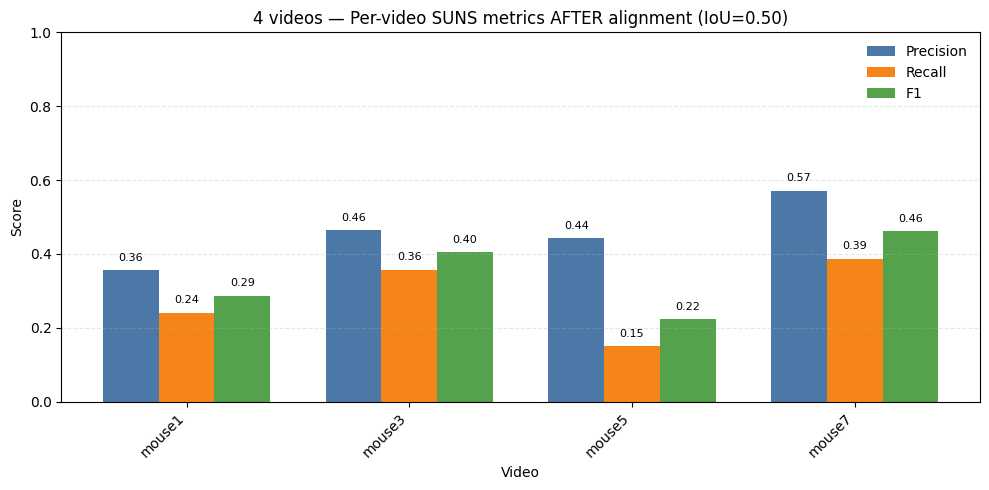

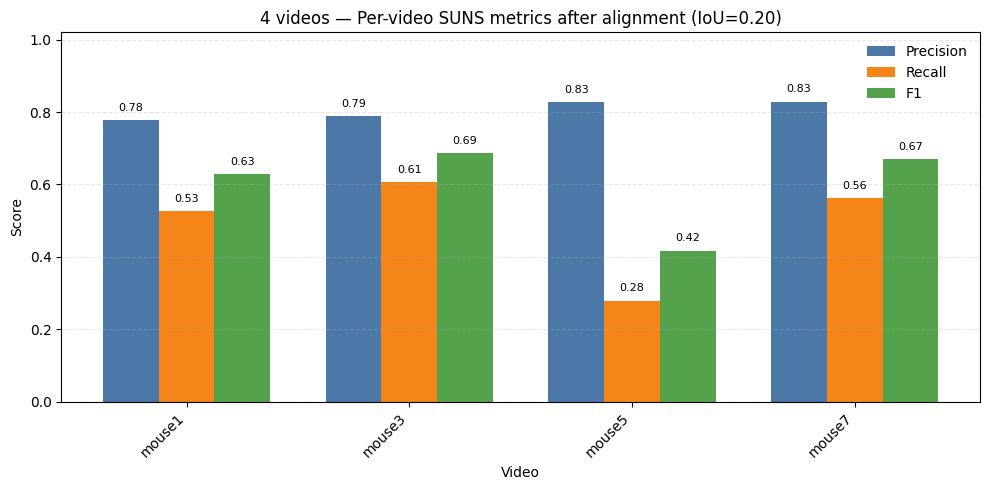


=== Running analysis for: 8 videos (line3_8videos) — exp_id=mouse7 ===
dir_parent: /gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3_8videos
Aligned: raw=256x256 -> net_in=256x256; N_GT=1104, N_pred=676


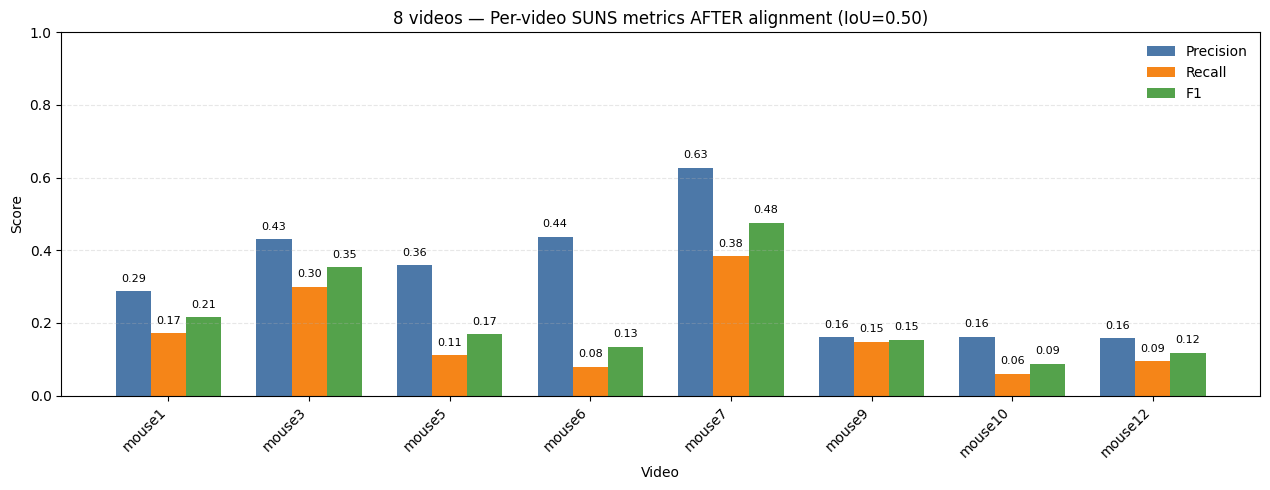

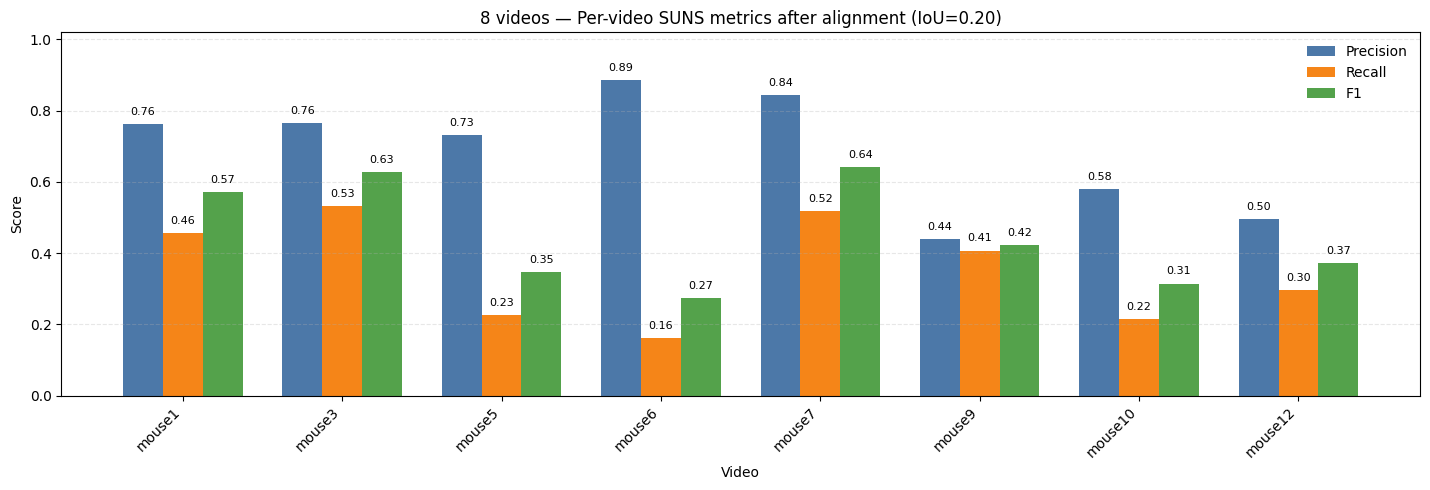


=== Running analysis for: 10 videos (line3_dataset) — exp_id=mouse7 ===
dir_parent: /gpfs/home/bizzin01/nicole/code/SUNS_nicole_git/Shallow-UNet-Neuron-Segmentation_SUNS/demo/line3_dataset/output_line3
Aligned: raw=256x256 -> net_in=256x256; N_GT=1104, N_pred=562


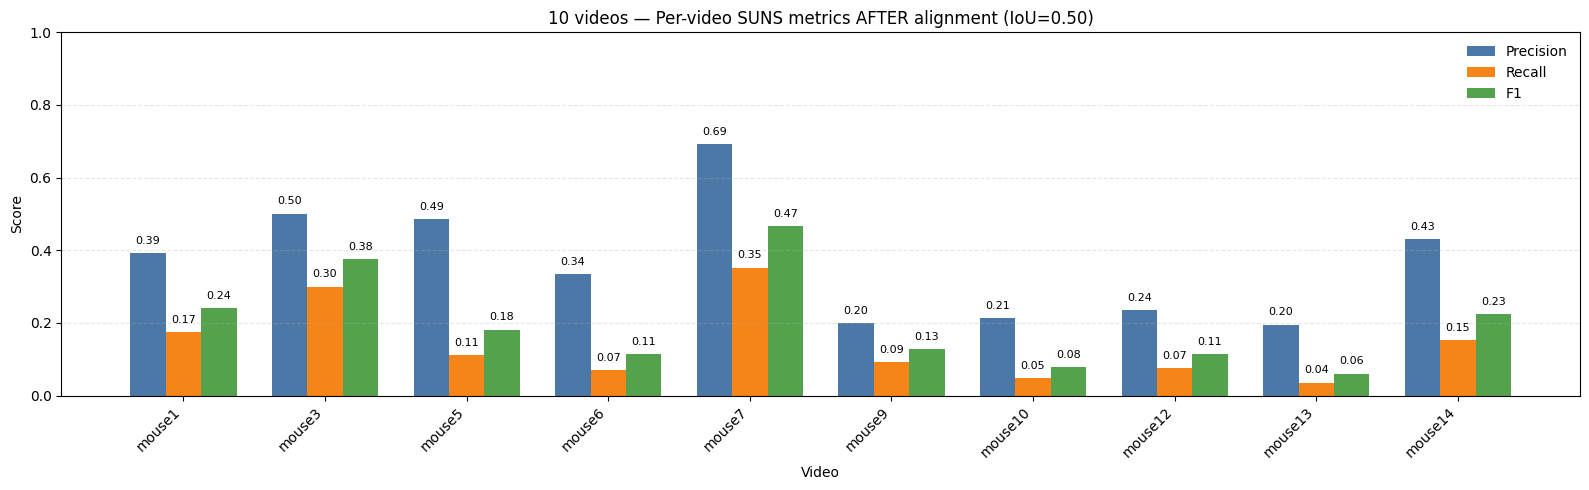

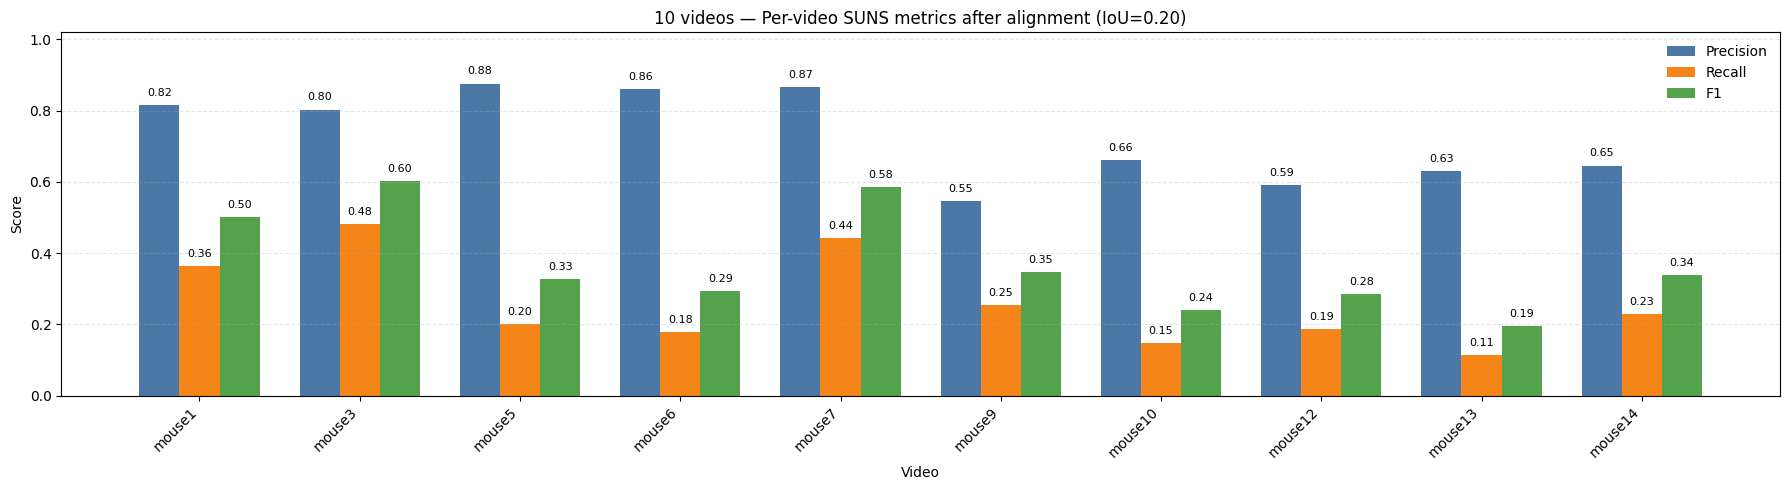

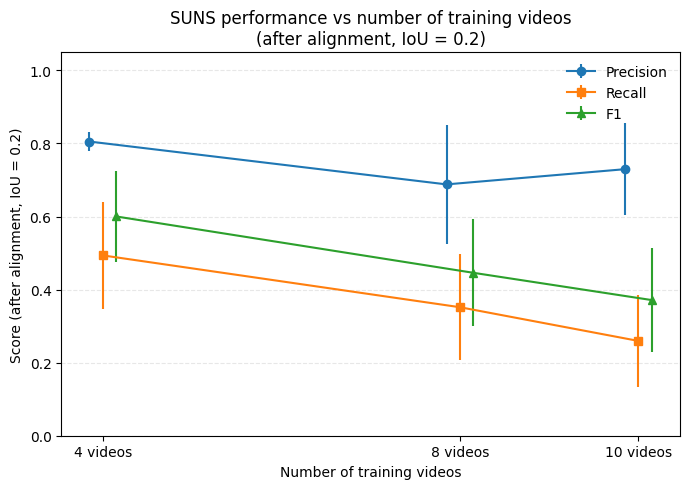

In [26]:
# --- Function: run full analysis for a single dataset (folder) ---
from typing import Dict, List, Optional, Any
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy import sparse
from suns.PostProcessing.evaluate import GetPerformance_Jaccard_2
from itertools import product

# --- alignment scoring helper ---

def _score_alignment(masks_bool: np.ndarray, img_f32: np.ndarray) -> float:
    if masks_bool.size == 0:
        return -np.inf
    if masks_bool.ndim == 3:
        union = np.any(masks_bool, axis=0)
    elif masks_bool.ndim == 2:
        union = masks_bool
    else:
        return -np.inf
    area = int(union.sum())
    if area == 0:
        return -np.inf
    return float(img_f32[union].mean())


# all 4 rotations × flipud × fliplr
combos = [(k, u, l) for k in range(4) for u in (False, True) for l in (False, True)]


def _best_transform_for_masks(masks_src: np.ndarray,
                              src_dims,
                              tgt_dims,
                              img_tgt: np.ndarray):
    best = (-np.inf, 0, False, False, None)
    for rk, fud, flr in combos:
        m_tf = transform_masks(masks_src, rot_k=rk, flip_ud=fud, flip_lr=flr)
        if m_tf.shape[1:] != tgt_dims:
            m_tf = pad_masks_top_left(m_tf, tgt_dims)
        score = _score_alignment(m_tf, img_tgt)
        if score > best[0]:
            best = (score, rk, fud, flr, m_tf)
    return best


def run_line3_analysis_for_dataset(
    ds: Dict[str, Any],
    exp_id: Optional[str] = None,
    iou_eval_after: float = 0.50,
    iou_eval: float = 0.20
) -> Dict[str, Any]:
    # unpack
    label = ds['label']
    set_key = ds['set_key']
    dir_video = ds['dir_video']
    dir_parent = ds['dir_parent']
    dir_net_in = ds['dir_net_in']
    dir_output = ds['dir_output']
    list_Exp_ID: List[str] = list(ds['list_Exp_ID'])

    if exp_id is None:
        exp_id = 'mouse7' if 'mouse7' in list_Exp_ID else list_Exp_ID[0]

    print(f"\n=== Running analysis for: {label} ({set_key}) — exp_id={exp_id} ===")
    print('dir_parent:', dir_parent)

    # Expose globals so existing helpers/plots use the correct context
    globals().update({
        'exp_id': exp_id,
        'dir_video': dir_video,
        'dir_parent': dir_parent,
        'dir_net_in': dir_net_in,
        'dir_output': dir_output,
    })

    # ---------------- Load SNR stack if available; else raw ----------------
    h5_net_in = os.path.join(dir_net_in, f'{exp_id}.h5')
    raw_h5 = os.path.join(dir_video, f'{exp_id}.h5')

    if os.path.exists(h5_net_in):
        with h5py.File(h5_net_in, 'r') as f:
            network_input = np.array(f['network_input'])  # (T, Lx, Ly)
        globals()['network_input'] = network_input
        T, Lx, Ly = network_input.shape
        max_img = network_input.max(axis=0).astype(np.float32)
        vmin, vmax = float(max_img.min()), float(max_img.max())
        if vmax > vmin:
            max_img = (max_img - vmin) / (vmax - vmin)
    else:
        assert os.path.exists(raw_h5), f'Missing video: {raw_h5}'
        max_img = compute_max_projection_from_h5(raw_h5)
        Lx, Ly = max_img.shape

    gt_sparse = os.path.join(dir_video, 'GT Masks', f'FinalMasks_{exp_id}_sparse.mat')
    pred_mat = os.path.join(dir_output, f'Output_Masks_{exp_id}.mat')

    gt_masks = load_gt_sparse_masks(gt_sparse, (Lx, Ly)) if os.path.exists(gt_sparse) else np.zeros((0, Lx, Ly), dtype=bool)
    pred_masks = load_pred_masks_from_mat(pred_mat, (Lx, Ly)) if os.path.exists(pred_mat) else np.zeros((0, Lx, Ly), dtype=bool)

    # ---------------- Alignment target dims ----------------
    with h5py.File(raw_h5, 'r') as f:
        dset_name = find_dataset(f)
        Lx_raw, Ly_raw = f[dset_name].shape[1:3]

    if 'network_input' in globals():
        Lx_net, Ly_net = network_input.shape[1:]
        max_img_net = network_input.max(axis=0).astype(np.float32)
        vmin_, vmax_ = float(max_img_net.min()), float(max_img_net.max())
        if vmax_ > vmin_:
            max_img_net = (max_img_net - vmin_) / (vmax_ - vmin_)
    else:
        Lx_net, Ly_net = Lx, Ly
        max_img_net = max_img.astype(np.float32)

    gt_masks_raw = load_gt_sparse_masks(gt_sparse, (Lx_raw, Ly_raw)) if os.path.exists(gt_sparse) else np.zeros((0, Lx_raw, Ly_raw), dtype=bool)

    _, GT_ROT_K, GT_FLIPUD, GT_FLIPLR, gt_masks_aligned = _best_transform_for_masks(
        gt_masks_raw, (Lx_raw, Ly_raw), (Lx_net, Ly_net), max_img_net
    )
    if pred_masks.shape[1:] == (Lx_raw, Ly_raw):
        _, PRED_ROT_K, PRED_FLIPUD, PRED_FLIPLR, pred_masks_aligned = _best_transform_for_masks(
            pred_masks, (Lx_raw, Ly_raw), (Lx_net, Ly_net), max_img_net
        )
    else:
        _, PRED_ROT_K, PRED_FLIPUD, PRED_FLIPLR, pred_masks_aligned = _best_transform_for_masks(
            pred_masks, pred_masks.shape[1:], (Lx_net, Ly_net), max_img_net
        )

    globals().update({
        'gt_masks': gt_masks_aligned,
        'pred_masks': pred_masks_aligned,
        'max_img': max_img_net,
        'Lx': Lx_net, 'Ly': Ly_net,
        'GT_ROT_K': GT_ROT_K, 'GT_FLIPUD': GT_FLIPUD, 'GT_FLIPLR': GT_FLIPLR,
        'PRED_ROT_K': PRED_ROT_K, 'PRED_FLIPUD': PRED_FLIPUD, 'PRED_FLIPLR': PRED_FLIPLR,
    })
    print(f"Aligned: raw={Lx_raw}x{Ly_raw} -> net_in={Lx_net}x{Ly_net}; "
          f"N_GT={gt_masks_aligned.shape[0]}, N_pred={pred_masks_aligned.shape[0]}")

    # ---------------- Metrics AFTER alignment (IoU = iou_eval_after) ----------------
    exp_ids = list(list_Exp_ID)
    P_after, R_after, F_after = [], [], []
    for eid in exp_ids:
        raw_h5_e = os.path.join(dir_video, f'{eid}.h5')
        gt_sparse_e = os.path.join(dir_video, 'GT Masks', f'FinalMasks_{eid}_sparse.mat')
        pred_mat_e = os.path.join(dir_output, f'Output_Masks_{eid}.mat')

        h5_net_in_e = os.path.join(dir_net_in, f'{eid}.h5')
        if os.path.exists(h5_net_in_e):
            with h5py.File(h5_net_in_e, 'r') as f:
                net_in_e = np.array(f['network_input'])
            Lx_net_e, Ly_net_e = net_in_e.shape[1:]
            max_img_net_e = net_in_e.max(axis=0).astype(np.float32)
            vmin_, vmax_ = float(max_img_net_e.min()), float(max_img_net_e.max())
            if vmax_ > vmin_:
                max_img_net_e = (max_img_net_e - vmin_) / (vmax_ - vmin_)
        else:
            with h5py.File(raw_h5_e, 'r') as f:
                dset_name_e = find_dataset(f)
                Lx_net_e, Ly_net_e = f[dset_name_e].shape[1:3]
                max_img_net_e = compute_max_projection_from_h5(raw_h5_e)

        with h5py.File(raw_h5_e, 'r') as f:
            dset_name_e = find_dataset(f)
            Lx_raw_e, Ly_raw_e = f[dset_name_e].shape[1:3]

        gt_raw_e = load_gt_sparse_masks(gt_sparse_e, (Lx_raw_e, Ly_raw_e)) if os.path.exists(gt_sparse_e) else np.zeros((0, Lx_raw_e, Ly_raw_e), dtype=bool)
        pred_e = load_pred_masks_from_mat(pred_mat_e, (Lx_raw_e, Ly_raw_e)) if os.path.exists(pred_mat_e) else np.zeros((0, Lx_raw_e, Ly_raw_e), dtype=bool)

        _, _, _, _, gt_aligned_e = _best_transform_for_masks(gt_raw_e, (Lx_raw_e, Ly_raw_e), (Lx_net_e, Ly_net_e), max_img_net_e)
        if pred_e.shape[1:] == (Lx_raw_e, Ly_raw_e):
            _, _, _, _, pred_aligned_e = _best_transform_for_masks(pred_e, (Lx_raw_e, Ly_raw_e), (Lx_net_e, Ly_net_e), max_img_net_e)
        else:
            _, _, _, _, pred_aligned_e = _best_transform_for_masks(pred_e, pred_e.shape[1:], (Lx_net_e, Ly_net_e), max_img_net_e)

        GT_csr = sparse.csr_matrix(gt_aligned_e.reshape(gt_aligned_e.shape[0], -1).astype(np.uint32))
        PR_csr = sparse.csr_matrix(pred_aligned_e.reshape(pred_aligned_e.shape[0], -1).astype(np.uint32))
        ThreshJ = 1.0 - float(iou_eval_after)
        R, P, F1 = GetPerformance_Jaccard_2(GT_csr, PR_csr, ThreshJ=ThreshJ)
        P_after.append(float(P)); R_after.append(float(R)); F_after.append(float(F1))

    N = len(exp_ids); x = np.arange(N); w = 0.25
    plt.figure(figsize=(max(10, 1.6*N), 5))
    plt.bar(x - w, P_after, width=w, label='Precision', color='#4C78A8')
    plt.bar(x,      R_after, width=w, label='Recall',    color='#F58518')
    plt.bar(x + w,  F_after, width=w, label='F1',        color='#54A24B')
    plt.xticks(x, exp_ids, rotation=45, ha='right')
    plt.ylim(0, 1.0); plt.xlabel('Video'); plt.ylabel('Score')
    plt.title(f'{label} — Per-video SUNS metrics AFTER alignment (IoU={iou_eval_after:.2f})')
    plt.grid(True, axis='y', linestyle='--', alpha=0.3); plt.legend(frameon=False)
    for i in range(N):
        for j, v in enumerate([P_after[i], R_after[i], F_after[i]]):
            xpos = x[i] + (j-1)*w
            plt.text(xpos, min(0.98, v + 0.02), f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout(); plt.show()

    # ---------------- Alternate IoU (iou_eval) – this is the one we summarize ----------------
    precision_list, recall_list, f1_list = [], [], []
    for eid in exp_ids:
        raw_h5_e = os.path.join(dir_video, f'{eid}.h5')
        gt_sparse_e = os.path.join(dir_video, 'GT Masks', f'FinalMasks_{eid}_sparse.mat')
        pred_mat_e = os.path.join(dir_output, f'Output_Masks_{eid}.mat')

        h5_net_in_e = os.path.join(dir_net_in, f'{eid}.h5')
        if os.path.exists(h5_net_in_e):
            with h5py.File(h5_net_in_e, 'r') as f:
                net_in_e = np.array(f['network_input'])
            Lx_net_e, Ly_net_e = net_in_e.shape[1:]
            max_img_net_e = net_in_e.max(axis=0).astype(np.float32)
            vmin_, vmax_ = float(max_img_net_e.min()), float(max_img_net_e.max())
            if vmax_ > vmin_:
                max_img_net_e = (max_img_net_e - vmin_) / (vmax_ - vmin_)
        else:
            with h5py.File(raw_h5_e, 'r') as f:
                dset_name_e = find_dataset(f)
                Lx_net_e, Ly_net_e = f[dset_name_e].shape[1:3]
                max_img_net_e = compute_max_projection_from_h5(raw_h5_e)

        with h5py.File(raw_h5_e, 'r') as f:
            dset_name_e = find_dataset(f)
            Lx_raw_e, Ly_raw_e = f[dset_name_e].shape[1:3]

        gt_raw_e = load_gt_sparse_masks(gt_sparse_e, (Lx_raw_e, Ly_raw_e)) if os.path.exists(gt_sparse_e) else np.zeros((0, Lx_raw_e, Ly_raw_e), dtype=bool)
        pred_e = load_pred_masks_from_mat(pred_mat_e, (Lx_raw_e, Ly_raw_e)) if os.path.exists(pred_mat_e) else np.zeros((0, Lx_raw_e, Ly_raw_e), dtype=bool)

        _, _, _, _, gt_aligned_e = _best_transform_for_masks(gt_raw_e, (Lx_raw_e, Ly_raw_e), (Lx_net_e, Ly_net_e), max_img_net_e)
        if pred_e.shape[1:] == (Lx_raw_e, Ly_raw_e):
            _, _, _, _, pred_aligned_e = _best_transform_for_masks(pred_e, (Lx_raw_e, Ly_raw_e), (Lx_net_e, Ly_net_e), max_img_net_e)
        else:
            _, _, _, _, pred_aligned_e = _best_transform_for_masks(pred_e, pred_e.shape[1:], (Lx_net_e, Ly_net_e), max_img_net_e)

        GTMasks_csr_e = sparse.csr_matrix(gt_aligned_e.reshape(gt_aligned_e.shape[0], -1).astype(np.uint32))
        PredMasks_csr_e = sparse.csr_matrix(pred_aligned_e.reshape(pred_aligned_e.shape[0], -1).astype(np.uint32))
        ThreshJ = 1.0 - float(iou_eval)  # IoU threshold for final metrics (e.g. 0.2)
        R, P, F1 = GetPerformance_Jaccard_2(GTMasks_csr_e, PredMasks_csr_e, ThreshJ=ThreshJ)
        precision_list.append(float(P)); recall_list.append(float(R)); f1_list.append(float(F1))

    x = np.arange(len(exp_ids)); w = 0.25
    plt.figure(figsize=(max(10, 1.8*len(exp_ids)), 5))
    plt.bar(x - w, precision_list, width=w, label='Precision', color='#4C78A8')
    plt.bar(x,      recall_list,    width=w, label='Recall',    color='#F58518')
    plt.bar(x + w,  f1_list,        width=w, label='F1',        color='#54A24B')
    plt.xticks(x, exp_ids, rotation=45, ha='right')
    plt.ylim(0, 1.02); plt.xlabel('Video'); plt.ylabel('Score')
    plt.title(f'{label} — Per-video SUNS metrics after alignment (IoU={iou_eval:.2f})')
    plt.grid(True, axis='y', linestyle='--', alpha=0.3); plt.legend(frameon=False)
    for i in range(len(exp_ids)):
        for j, v in enumerate([precision_list[i], recall_list[i], f1_list[i]]):
            xpos = x[i] + (j-1)*w
            plt.text(xpos, min(0.98, v + 0.02), f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout(); plt.show()

    # -------- aggregate metrics across videos and RETURN them --------
    precision_arr = np.array(precision_list)
    recall_arr    = np.array(recall_list)
    f1_arr        = np.array(f1_list)

    summary = {
        'label'          : label,
        'set_key'        : set_key,
        'n_train_videos' : len(list_Exp_ID),      # 4, 8, 10
        'exp_ids'        : exp_ids,
        'precision'      : precision_arr,
        'recall'         : recall_arr,
        'f1'             : f1_arr,
        'precision_mean' : float(precision_arr.mean()) if precision_arr.size > 0 else 0.0,
        'recall_mean'    : float(recall_arr.mean())    if recall_arr.size > 0 else 0.0,
        'f1_mean'        : float(f1_arr.mean())        if f1_arr.size > 0 else 0.0,
        'precision_std'  : float(precision_arr.std(ddof=1)) if precision_arr.size > 1 else 0.0,
        'recall_std'     : float(recall_arr.std(ddof=1))    if recall_arr.size > 1 else 0.0,
        'f1_std'         : float(f1_arr.std(ddof=1))        if f1_arr.size > 1 else 0.0,
        'iou'            : float(iou_eval),
    }

    return summary


# ---------------- Runner: build datasets and run analysis ----------------
import importlib
from suns import config as suns_config
importlib.reload(suns_config)

ACTIVE_SETS = [
    ('mouse7 4 videos',  '4videos_mouse7'),
    ('mouse7 8 videos',  '8videos_mouse7'),
]

PARENT_OVERRIDES = {}
for k in ['4videos_mouse7', '8videos_mouse7']:
    PARENT_OVERRIDES[k] = os.path.join(suns_config.DATAFOLDER_SETS[k], suns_config.OUTPUT_FOLDER[k])

DATASETS: List[Dict[str, Any]] = []
for label, set_key in ACTIVE_SETS:
    list_Exp_ID = suns_config.EXP_ID_SETS[set_key]
    dir_video = suns_config.DATAFOLDER_SETS[set_key]
    parent = PARENT_OVERRIDES.get(set_key)
    ds = {
        'label': label,
        'set_key': set_key,
        'list_Exp_ID': list_Exp_ID,
        'dir_video': dir_video,
        'dir_parent': parent,
        'dir_net_in': os.path.join(parent, 'network_input'),
        'dir_output': os.path.join(parent, 'output_masks'),
    }
    DATASETS.append(ds)

summaries: List[Dict[str, Any]] = []

for ds in DATASETS:
    eid = 'mouse7' if 'mouse7' in ds['list_Exp_ID'] else ds['list_Exp_ID'][0]
    summary = run_line3_analysis_for_dataset(
        ds,
        exp_id=eid,
        iou_eval_after=0.50,   # keep IoU=0.5 barplots
        iou_eval=0.20          # IoU=0.2 for comparison plot
    )
    summaries.append(summary)

# ---------- Final comparison plot: 4 vs 8 vs 10 videos (IoU=0.2, after alignment) ----------
summaries = sorted(summaries, key=lambda s: s['n_train_videos'])

x_vals = np.array([s['n_train_videos'] for s in summaries], dtype=float)  # [4, 8, 10]
x_labels = [f"{int(n)} videos" for n in x_vals]

P_means = np.array([s['precision_mean'] for s in summaries])
R_means = np.array([s['recall_mean']    for s in summaries])
F_means = np.array([s['f1_mean']        for s in summaries])

P_stds  = np.array([s['precision_std'] for s in summaries])
R_stds  = np.array([s['recall_std']    for s in summaries])
F_stds  = np.array([s['f1_std']        for s in summaries])

plt.figure(figsize=(7, 5))
offset = 0.15

plt.errorbar(x_vals - offset, P_means, yerr=P_stds, fmt='o-', label='Precision')
plt.errorbar(x_vals,          R_means, yerr=R_stds, fmt='s-', label='Recall')
plt.errorbar(x_vals + offset, F_means, yerr=F_stds, fmt='^-', label='F1')

plt.xticks(x_vals, x_labels)
plt.ylim(0, 1.05)
plt.xlabel('Number of training videos')
plt.ylabel('Score (after alignment, IoU = 0.2)')
plt.title('SUNS performance vs number of training videos\n(after alignment, IoU = 0.2)')
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
